# Face Detection with Convolutional Neural Networks


In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mtcnn.mtcnn import MTCNN

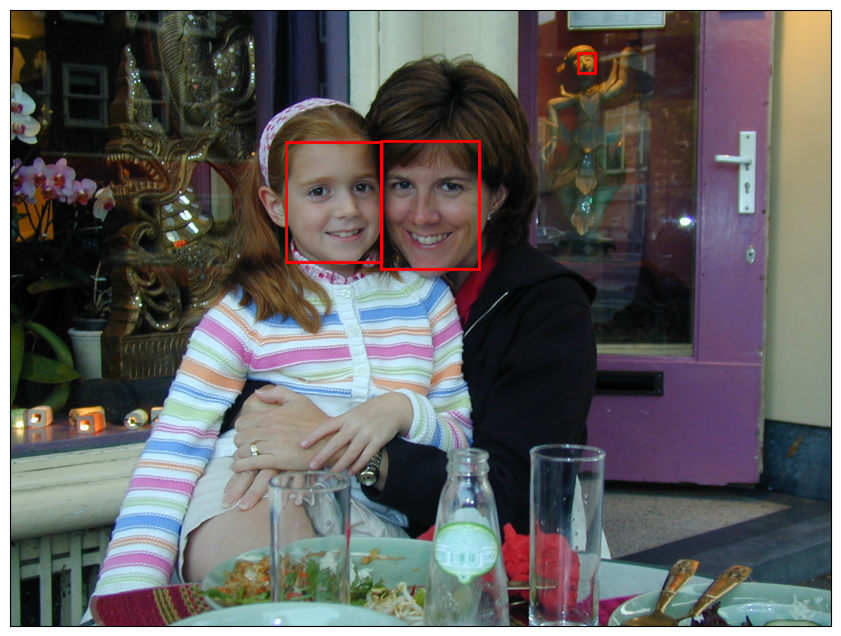

In [4]:
image = plt.imread("Data/Amsterdam.jpg")
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"xticks": [], "yticks": []})
ax.imshow(image)


detector = MTCNN()
faces = detector.detect_faces(image)

for face in faces:
    x, y, w, h = face["box"]
    rect = Rectangle((x, y), w, h, color="red", fill=False, lw=2)
    ax.add_patch(rect)

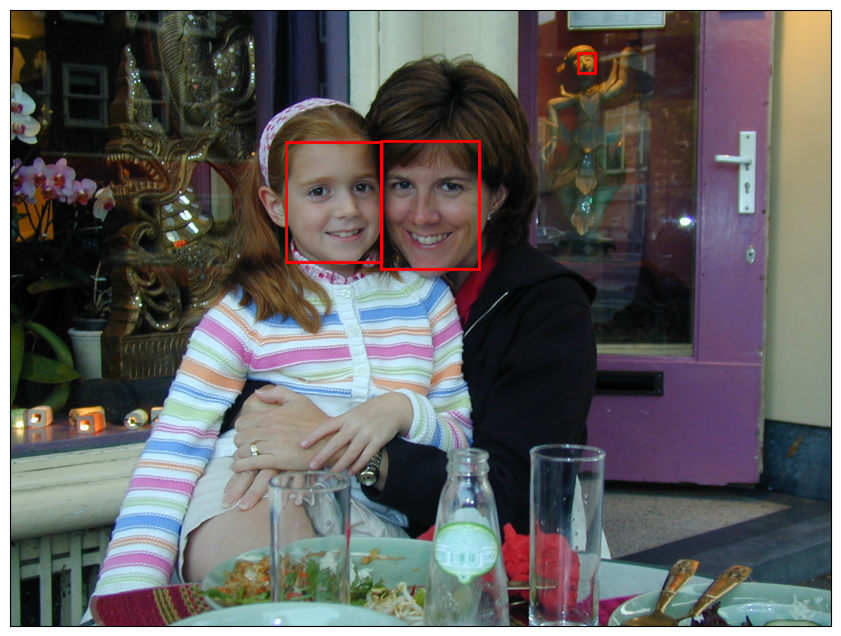

In [5]:
image = plt.imread("Data/Amsterdam.jpg")
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"xticks": [], "yticks": []})
ax.imshow(image)


faces = detector.detect_faces(image)

for face in faces:
    if face["confidence"] > 0.9:
        x, y, w, h = face["box"]
        rect = Rectangle((x, y), w, h, color="red", fill=False, lw=2)
        ax.add_patch(rect)

## Extracing Faces from Photos

In [7]:
import numpy as np
from mtcnn.mtcnn import MTCNN
from PIL import Image, ImageOps


def extract_faces(input_file, min_confidence=0.9, crop=True):
    # Load the image and orient it correctly.
    pil_image = Image.open(input_file)
    exif = pil_image.getexif()
    for k in exif.keys():
        if (
            k != 0x0112
        ):  # In EXIF data, 0x0112 (or 274 in decimal) represents the Orientation tag, which indicates how an image should be displayed
            exif[k] = None
            del exif[k]
    pil_image.info["exif"] = exif.tobytes()
    pil_image = ImageOps.exif_transpose(pil_image)
    image = np.array(pil_image)

    # Find the faces in the image.
    detector = MTCNN()
    faces = detector.detect_faces(image)
    faces = [face for face in faces if face["confidence"] >= min_confidence]
    results = []

    for face in faces:
        x1, y1, w, h = face["box"]

        if crop:
            # Compute crop coordinates.
            if w > h:
                x1 = x1 + ((w - h) // 2)
                w = h
            elif h > w:
                y1 = y1 + ((h - w) // 2)
                h = w

        # Extract the facial image and add it to the list.
        x2 = x1 + w
        y2 = y1 + h

        results.append(Image.fromarray(image[y1:y2, x1:x2]))

    # Return all the facial images.
    return results

In [8]:
faces = extract_faces("Data/Amsterdam.jpg")

for i, face in enumerate(faces):
    face.resize((224, 224)).save(f"face{i}.jpg")